 # import python lib:

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\power BI\Dataset\customer_dim.csv", encoding='latin1')
df2 = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\power BI\Dataset\fact_table.csv", encoding='latin1')
df3 = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\power BI\Dataset\item_dim.csv", encoding='latin1')
df4 = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\power BI\Dataset\store_dim.csv", encoding='latin1')
df5 = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\power BI\Dataset\time_dim.csv", encoding='latin1')
df6 = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\power BI\Dataset\Trans_dim.csv", encoding='latin1')

In [94]:
print("customer_dim")
print(df.columns.tolist())

print("\nfact_table")
print(df2.columns.tolist())

print("\nitem_dim")
print(df3.columns.tolist())

print("\nstore_dim")
print(df4.columns.tolist())

print("\ntime_dim")
print(df5.columns.tolist())

print("\nTrans_dim")
print(df6.columns.tolist())

customer_dim
['coustomer_key', 'name', 'contact_no', 'nid']

fact_table
['payment_key', 'coustomer_key', 'time_key', 'item_key', 'store_key', 'quantity', 'unit', 'unit_price', 'total_price']

item_dim
['item_key', 'item_name', 'desc', 'unit_price', 'man_country', 'supplier', 'unit']

store_dim
['store_key', 'division', 'district', 'upazila']

time_dim
['time_key', 'date', 'hour', 'day', 'week', 'month', 'quarter', 'year']

Trans_dim
['payment_key', 'trans_type', 'bank_name']


# JOIN ALL TABLES :

In [95]:
merged = (
    df2
    .merge(df, on='coustomer_key', how='left')
    .merge(df3, on='item_key', how='left')
    .merge(df4, on='store_key', how='left')
    .merge(df5, on='time_key', how='left')
    .merge(df6, on='payment_key', how='left')
)

print(merged.head())

  payment_key coustomer_key time_key item_key store_key  quantity unit_x  \
0        P026       C004510  T049189   I00177    S00307         1     ct   
1        P022       C008967  T041209   I00248    S00595         1  rolls   
2        P030       C007261   T03633   I00195    S00496         8     ct   
3        P032       C007048  T084631   I00131     S0086         8     ct   
4        P014       C006430  T071276   I00050    S00488         8   cans   

   unit_price_x  total_price           name  ...     upazila  \
0          35.0         35.0          priya  ...    ISLAMPUR   
1          26.0         26.0  harpreet kaur  ...  CANTONMENT   
2          12.5        100.0          sonam  ...   BEGUMGANJ   
3          14.0        112.0      rekha bai  ...      KAUNIA   
4           8.0         64.0     mamta devi  ...   MATIRANGA   

               date hour day      week month quarter  year trans_type  \
0  26-04-2016 17:13   17  26  4th Week     4      Q2  2016       card   
1  11-06-201

In [96]:
merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 30 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   payment_key    1000000 non-null  str    
 1   coustomer_key  1000000 non-null  str    
 2   time_key       1000000 non-null  str    
 3   item_key       1000000 non-null  str    
 4   store_key      1000000 non-null  str    
 5   quantity       1000000 non-null  int64  
 6   unit_x         996277 non-null   str    
 7   unit_price_x   1000000 non-null  float64
 8   total_price    1000000 non-null  float64
 9   name           997010 non-null   str    
 10  contact_no     1000000 non-null  int64  
 11  nid            1000000 non-null  int64  
 12  item_name      1000000 non-null  str    
 13  desc           1000000 non-null  str    
 14  unit_price_y   1000000 non-null  float64
 15  man_country    1000000 non-null  str    
 16  supplier       1000000 non-null  str    
 17  unit_y         99627

In [97]:
merged.isnull().sum()

payment_key          0
coustomer_key        0
time_key             0
item_key             0
store_key            0
quantity             0
unit_x            3723
unit_price_x         0
total_price          0
name              2990
contact_no           0
nid                  0
item_name            0
desc                 0
unit_price_y         0
man_country          0
supplier             0
unit_y            3723
division             0
district             0
upazila              0
date                 0
hour                 0
day                  0
week                 0
month                0
quarter              0
year                 0
trans_type           0
bank_name        25590
dtype: int64

<!-- FILLING EMPTY ROWS OF COLOUMN BANK_NAME: -->

In [98]:
merged['bank_name'] = merged['bank_name'].fillna('Cash Payment')

In [99]:
merged['unit_y'].unique()

<ArrowStringArray>
[      'ct',    'rolls',     'cans',  'bottles',     'bags',       'oz',
     'tubs',  'cartons',       'lb',     'tins',      'ct.',     'pack',
       'pk',     'bars',     'Bags',      'oz.',        nan,       'Ct',
 'botlltes']
Length: 19, dtype: str

In [100]:
merged['name'].isnull().sum()

np.int64(2990)

# Clean Customer Name Column

We are removing leading and trailing spaces from the 'name' column to ensure consistency in customer names.

This helps in avoiding duplicate entries caused by extra spaces.

In [101]:
merged['name'] = merged['name'].str.strip()

# Standardize Customer Name Format

We are converting the 'name' column into title case using .str.title() to ensure consistency in naming format.

This makes all customer names uniform (e.g., 'rahul kumar' → 'Rahul Kumar').

In [102]:
merged['name'] = merged['name'].str.title()

# Fill Missing Customer Names

Replace null values in 'name' column with 'Unknown' to maintain data consistency.

In [103]:
merged['name'] = merged['name'].fillna('Unknown')

# Drop Unit Column

Remove 'unit_x' column as it is not needed for further analysis.

In [104]:
merged=merged.drop(columns=['unit_x'])


# View First 5 Rows

Check sample records to verify data after preprocessing.

In [105]:
print(merged.head())

  payment_key coustomer_key time_key item_key store_key  quantity  \
0        P026       C004510  T049189   I00177    S00307         1   
1        P022       C008967  T041209   I00248    S00595         1   
2        P030       C007261   T03633   I00195    S00496         8   
3        P032       C007048  T084631   I00131     S0086         8   
4        P014       C006430  T071276   I00050    S00488         8   

   unit_price_x  total_price           name     contact_no  ...     upazila  \
0          35.0         35.0          Priya  8801529462805  ...    ISLAMPUR   
1          26.0         26.0  Harpreet Kaur  8801985295010  ...  CANTONMENT   
2          12.5        100.0          Sonam  8801955748165  ...   BEGUMGANJ   
3          14.0        112.0      Rekha Bai  8801927509185  ...      KAUNIA   
4           8.0         64.0     Mamta Devi  8801549045065  ...   MATIRANGA   

               date hour  day      week month quarter  year trans_type  \
0  26-04-2016 17:13   17   26  4th W

# Drop Irrelevant Columns

Remove unnecessary columns to keep dataset clean and focused for analysis.

In [106]:
merged=merged.drop(columns=['unit_y'])
merged=merged.drop(columns=['upazila'])
merged=merged.drop(columns=['contact_no'])
merged=merged.drop(columns=['nid'])

# View First 5 Rows

Check sample records to verify data after preprocessing.

In [107]:
print(merged.head())

  payment_key coustomer_key time_key item_key store_key  quantity  \
0        P026       C004510  T049189   I00177    S00307         1   
1        P022       C008967  T041209   I00248    S00595         1   
2        P030       C007261   T03633   I00195    S00496         8   
3        P032       C007048  T084631   I00131     S0086         8   
4        P014       C006430  T071276   I00050    S00488         8   

   unit_price_x  total_price           name  \
0          35.0         35.0          Priya   
1          26.0         26.0  Harpreet Kaur   
2          12.5        100.0          Sonam   
3          14.0        112.0      Rekha Bai   
4           8.0         64.0     Mamta Devi   

                            item_name  ...      district              date  \
0             M&M Peanut Candy 1.7 oz  ...      JAMALPUR  26-04-2016 17:13   
1           Charmin Ultra Bath Tissue  ...         DHAKA  11-06-2018 19:08   
2       Dole Fruit in Gel Cups 4.3 oz  ...      NOAKHALI  19-11-2016

# Check Date Column

View sample values from the 'date' column to verify format.

In [108]:
merged['date'].head()

0    26-04-2016 17:13
1    11-06-2018 19:08
2    19-11-2016 08:19
3    01-02-2020 06:00
4    15-07-2014 02:58
Name: date, dtype: str

In [81]:
merged.duplicated().sum()

np.int64(0)

In [82]:
merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 25 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   payment_key    1000000 non-null  str    
 1   coustomer_key  1000000 non-null  str    
 2   time_key       1000000 non-null  str    
 3   item_key       1000000 non-null  str    
 4   store_key      1000000 non-null  str    
 5   quantity       1000000 non-null  int64  
 6   unit_price_x   1000000 non-null  float64
 7   total_price    1000000 non-null  float64
 8   name           1000000 non-null  str    
 9   item_name      1000000 non-null  str    
 10  desc           1000000 non-null  str    
 11  unit_price_y   1000000 non-null  float64
 12  man_country    1000000 non-null  str    
 13  supplier       1000000 non-null  str    
 14  division       1000000 non-null  str    
 15  district       1000000 non-null  str    
 16  date           1000000 non-null  str    
 17  hour           10000

In [83]:
merged.describe()

,quantity,unit_price_x,total_price,unit_price_y,hour,day,month,year
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.00000,1000000.000000,1000000.000000
mean,6.000185,17.561602,105.401436,17.561602,11.542591,15.77572,6.518765,2017.050811
std,3.161932,8.637097,80.829301,8.637097,6.903028,8.80161,3.447577,2.016437
min,1.000000,6.000000,6.000000,6.000000,0.000000,1.00000,1.000000,2014.000000
25%,3.000000,13.000000,47.250000,13.000000,6.000000,8.00000,4.000000,2015.000000
50%,6.000000,16.000000,90.000000,16.000000,12.000000,16.00000,7.000000,2017.000000
75%,9.000000,20.000000,144.000000,20.000000,18.000000,23.00000,10.000000,2019.000000
max,11.000000,55.000000,605.000000,55.000000,23.000000,31.00000,12.000000,2021.000000


#                                                                 BUSINESS MATRIX

# Total Revenue

Sum of all values in 'total_price' column to get overall revenue.

In [84]:
Total_Revanue=merged['total_price'].sum()
print(Total_Revanue)

105401435.75


# Total Quantity

Sum of all values in 'quantity' column to get total units sold.

In [85]:
Total_Quantity=merged['quantity'].sum()
print(Total_Quantity)

6000185


# Unique Customers

Count of distinct customers who made transactions.

In [86]:
Total_Customer=merged['coustomer_key'].nunique()
print(Total_Customer)

9191


In [87]:
merged['payment_key'].size

1000000

# Average Revenue

Mean of 'total_price' column representing average order value per transaction.

In [88]:
merged['total_price'].mean()

np.float64(105.40143575)

# Revenue by Week

Total revenue aggregated at weekly level to analyze weekly sales trends.

In [89]:
merged.groupby('week')['total_price'].sum()

week
1st Week    24126620.25
2nd Week    24085895.75
3rd Week    24226544.50
4th Week    32962375.25
Name: total_price, dtype: float64

# Average Price per Unit

Total revenue divided by total quantity to find average selling price per unit.

In [109]:
merged['total_price'].sum()/merged['quantity'].sum()

np.float64(17.56636432876653)

# Revenue by Month

Total revenue aggregated at monthly level to analyze monthly performance trends.

In [110]:
merged.groupby('month')['total_price'].sum()

month
1     9042244.00
2     8073877.50
3     8939152.00
4     8504634.75
5     9078002.50
6     8556853.00
7     9046580.00
8     8929475.25
9     8724326.50
10    8902783.75
11    8680026.00
12    8923480.50
Name: total_price, dtype: float64

# PIE CHART

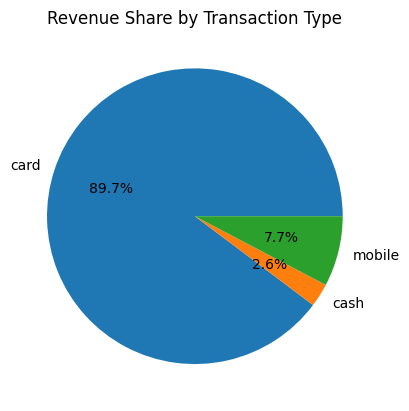

In [112]:
revenue_by_txn = (
    merged.groupby('trans_type')['total_price']
    .sum()
)

revenue_by_txn.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Revenue Share by Transaction Type')
plt.ylabel('')
plt.show()